# Iris Flower Classification

Classify iris flowers into **setosa**, **versicolor**, or **virginica** using sepal and petal measurements.


## 1. Load the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

RANDOM_STATE = 42

df = pd.read_csv("IRIS.csv")
print(df.shape)
df.head()


(150, 5)


   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa

## 2. Check class balance

The dataset is perfectly balanced: 50 samples of each species.

In [2]:
df["species"].value_counts()


species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50

## 3. Visualize the measurements

Petal measurements separate the species much more cleanly than sepal measurements — this hints that petal length/width will be the most useful features.

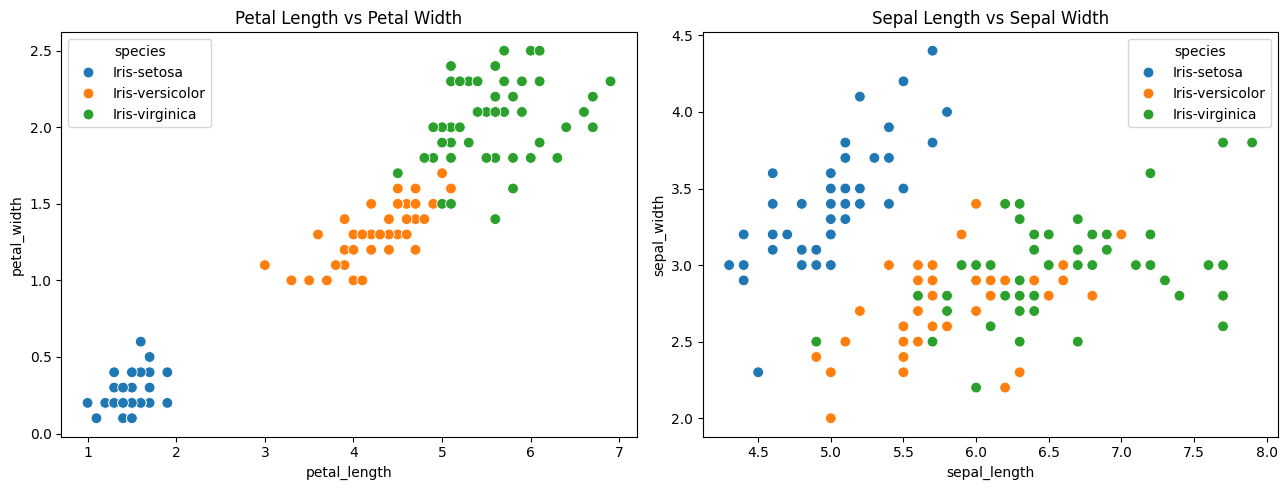

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=df, x="petal_length", y="petal_width", hue="species", ax=axes[0], s=60)
axes[0].set_title("Petal Length vs Petal Width")
sns.scatterplot(data=df, x="sepal_length", y="sepal_width", hue="species", ax=axes[1], s=60)
axes[1].set_title("Sepal Length vs Sepal Width")
plt.tight_layout()
plt.show()


## 4. Train / test split

A stratified split keeps the same class proportions in both the training and test sets. Features are standardized (zero mean, unit variance) since distance- and margin-based models (KNN, SVM, Logistic Regression) are sensitive to feature scale.

In [4]:
X = df.drop(columns=["species"])
y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 5. Train and compare several classifiers

Five common classification algorithms are compared using both a held-out test set and 5-fold cross-validation (for a more stable accuracy estimate on this small dataset).

In [5]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "SVM": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
}

results = []
fitted = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    cv_scores = cross_val_score(model, scaler.fit_transform(X), y, cv=5)
    results.append({
        "Model": name,
        "Test Accuracy": round(acc, 4),
        "CV Accuracy (mean)": round(cv_scores.mean(), 4),
        "CV Accuracy (std)": round(cv_scores.std(), 4),
    })
    fitted[name] = model

results_df = pd.DataFrame(results).sort_values("Test Accuracy", ascending=False)
results_df


                 Model  Test Accuracy  CV Accuracy (mean)  CV Accuracy (std)
4                  SVM         0.9667              0.9667             0.0211
0  Logistic Regression         0.9333              0.9600             0.0389
1  K-Nearest Neighbors         0.9333              0.9600             0.0249
2        Decision Tree         0.9000              0.9533             0.0340
3        Random Forest         0.9000              0.9600             0.0249

## 6. Evaluate the best model

A closer look at where the best model makes mistakes, using a classification report and confusion matrix.

In [6]:
best_name = results_df.iloc[0]["Model"]
best_model = fitted[best_name]
best_preds = best_model.predict(X_test_scaled)
print(f"Best model: {best_name}")
print()
print(classification_report(y_test, best_preds))
print("Confusion matrix:")
print(confusion_matrix(y_test, best_preds))


Best model: SVM

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30

Confusion matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


## 7. Feature importance

Which measurements matter most? (only available for tree-based models)

In [7]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    importances.sort_values(ascending=False)
else:
    print(f"{best_name} doesn't expose feature_importances_. Trying Random Forest instead:")
    rf = fitted["Random Forest"]
    importances = pd.Series(rf.feature_importances_, index=X.columns)
    importances.sort_values(ascending=False)


SVM doesn't expose feature_importances_. Trying Random Forest instead:


## 8. Try a prediction

Classify a new flower from its measurements.

In [8]:
def predict_species(sepal_length, sepal_width, petal_length, petal_width):
    row = pd.DataFrame([{
        "sepal_length": sepal_length, "sepal_width": sepal_width,
        "petal_length": petal_length, "petal_width": petal_width,
    }])
    row_scaled = scaler.transform(row)
    return best_model.predict(row_scaled)[0]

predict_species(5.1, 3.5, 1.4, 0.2)


'Iris-setosa'